# Desafío - Predicción de churn
## Daniel Rojas López

## Contexto del problema

En la industria de las telecomunicaciones la retención de clientes es un desafío clave. La fuga de clientes (*churn*) impacta significativamente los ingresos de la empresa, por lo que anticiparse a ella permite tomar medidas preventivas.

- **Unidad de análisis:** cada cliente de la empresa.
- **Variable objetivo:** `Churn` (cliente que abandona el servicio = "Sí").
- **Tipo de problema:** clasificación binaria supervisada.
- **Metodología:** análisis exploratorio, preprocesamiento, división entrenamiento/prueba, entrenamiento de varios algoritmos con optimización de hiperparámetros mediante validación cruzada y evaluación con métricas de clasificación.

## 1. Análisis exploratorio de los datos

Se cargará el dataset y se explorarán sus características: dimensiones, tipos de datos, valores nulos, duplicados y la distribución de las variables.

In [1]:
# Se importarán las librerías necesarias y se cargará el dataset de clientes de telecomunicaciones.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Se configurará el estilo de los gráficos.
sns.set_theme(style='whitegrid')
%matplotlib inline

df = pd.read_excel('Telco-Customer-Churn.xlsx')

# Se mostrarán las primeras filas del dataset.
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
# Se mostrará la información general del dataset: tipos de datos y cantidad de no nulos.
df.info()

# Se mostrará la cantidad de valores nulos por columna.
print('\nValores nulos por columna:')
print(df.isnull().sum())

# Se mostrará la cantidad de filas duplicadas.
print('\nFilas duplicadas:', df.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [3]:
# Se mostrará el resumen estadístico de las variables numéricas.
df[['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']].describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.00,0.000,0.0000,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.000,55.0000,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.350,89.8500,118.75
TotalCharges,7032.0,2283.300441,2266.771362,18.80,401.45,1397.475,3794.7375,8684.80


C:\Users\Daniel\AppData\Local\Temp\ipykernel_12172\2775887618.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Churn', data=df, ax=axes[0], palette=['#4C72B0', '#C44E52'])


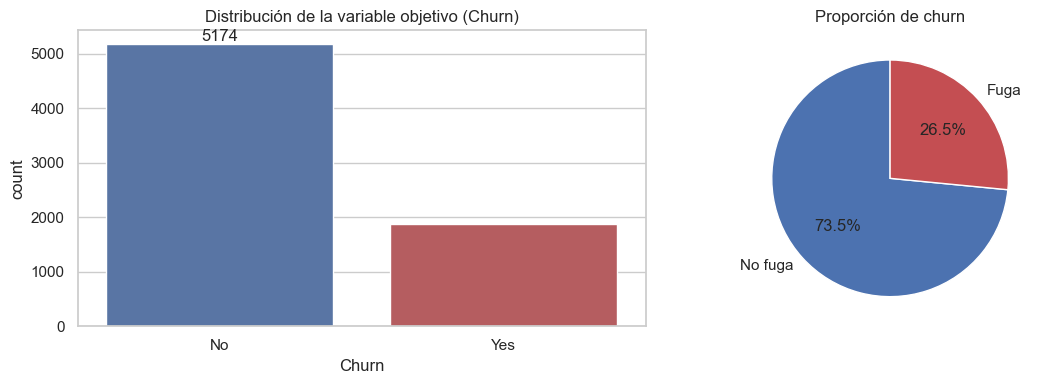

In [4]:
# Se analizará la distribución de la variable objetivo (churn).
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribución de la variable objetivo.
ax = sns.countplot(x='Churn', data=df, ax=axes[0], palette=['#4C72B0', '#C44E52'])
ax.bar_label(ax.containers[0])
axes[0].set_title('Distribución de la variable objetivo (Churn)')

# Proporción de churn.
proporcion = df['Churn'].value_counts(normalize=True)
axes[1].pie(proporcion, labels=['No fuga', 'Fuga'], autopct='%1.1f%%',
            colors=['#4C72B0', '#C44E52'], startangle=90)
axes[1].set_title('Proporción de churn')

plt.tight_layout()
plt.show()

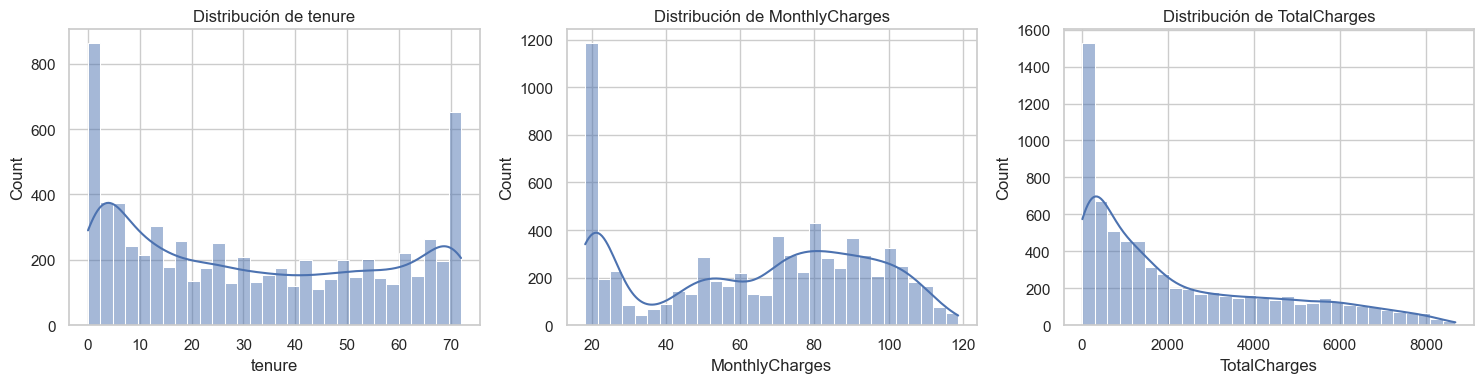

In [5]:
# Se analizará la distribución de las variables numéricas mediante histogramas.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['tenure', 'MonthlyCharges', 'TotalCharges']):
    sns.histplot(df[col], bins=30, kde=True, ax=ax)
    ax.set_title(f'Distribución de {col}')
plt.tight_layout()
plt.show()

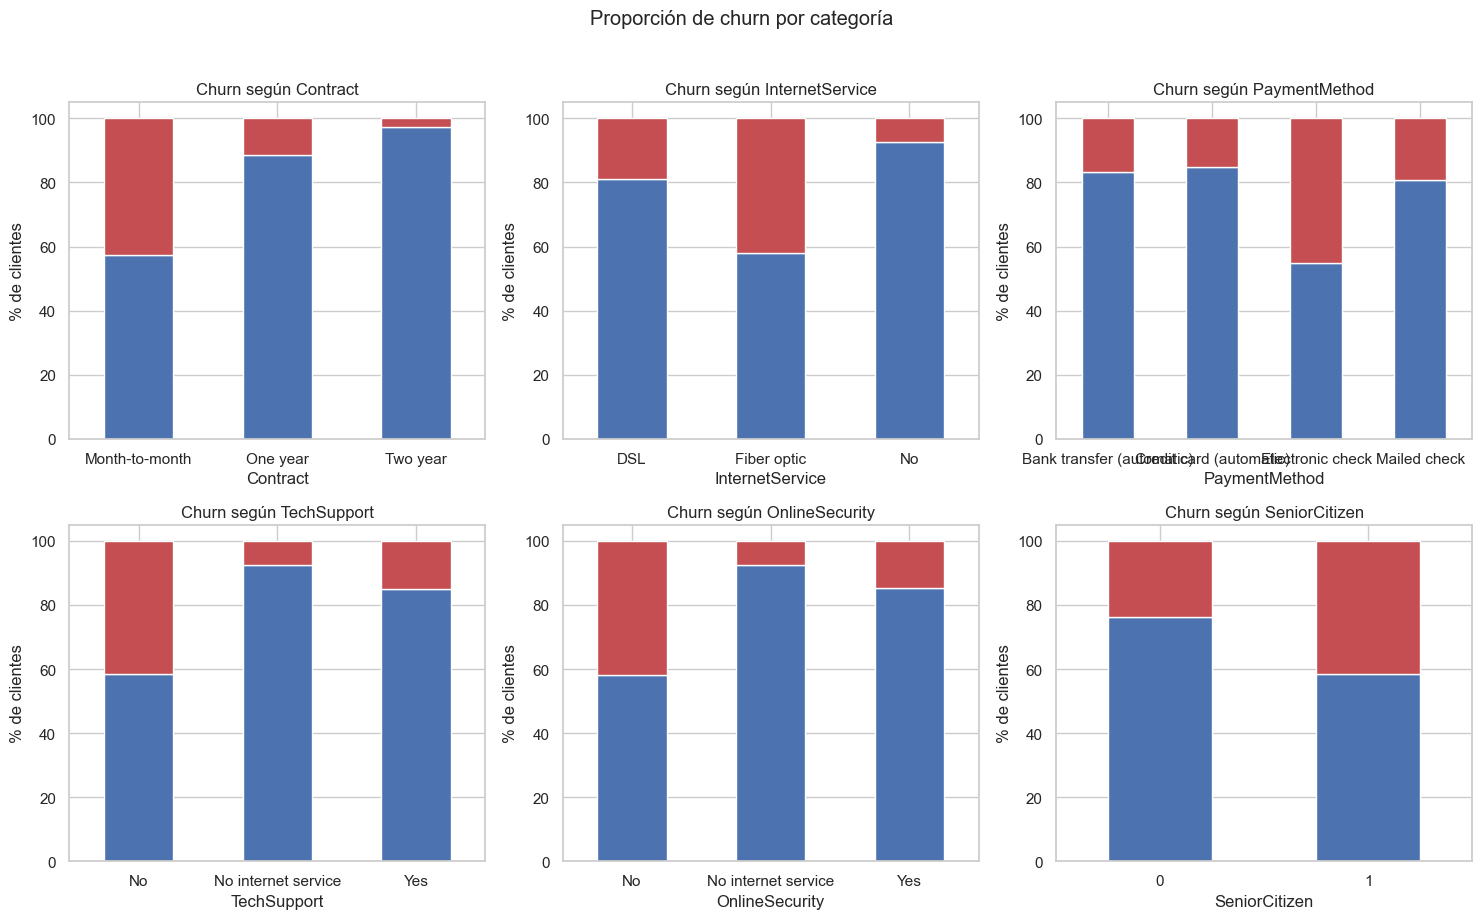

In [6]:
# Se comparará la relación entre variables categóricas clave y el churn.
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, col in zip(axes.ravel(), ['Contract', 'InternetService', 'PaymentMethod',
                                  'TechSupport', 'OnlineSecurity', 'SeniorCitizen']):
    datos_plot = pd.crosstab(df[col], df['Churn'], normalize='index') * 100
    datos_plot.plot(kind='bar', stacked=True, ax=ax, color=['#4C72B0', '#C44E52'], legend=False)
    ax.set_title(f'Churn según {col}')
    ax.set_ylabel('% de clientes')
    ax.tick_params(axis='x', rotation=0)
fig.suptitle('Proporción de churn por categoría', y=1.02)
plt.tight_layout()
plt.show()

C:\Users\Daniel\AppData\Local\Temp\ipykernel_12172\663761163.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y=col, data=df, ax=ax, palette=['#4C72B0', '#C44E52'])
C:\Users\Daniel\AppData\Local\Temp\ipykernel_12172\663761163.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y=col, data=df, ax=ax, palette=['#4C72B0', '#C44E52'])
C:\Users\Daniel\AppData\Local\Temp\ipykernel_12172\663761163.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y=col, data=df, ax=ax, palette=['#4C72B0', '#C44E52'])


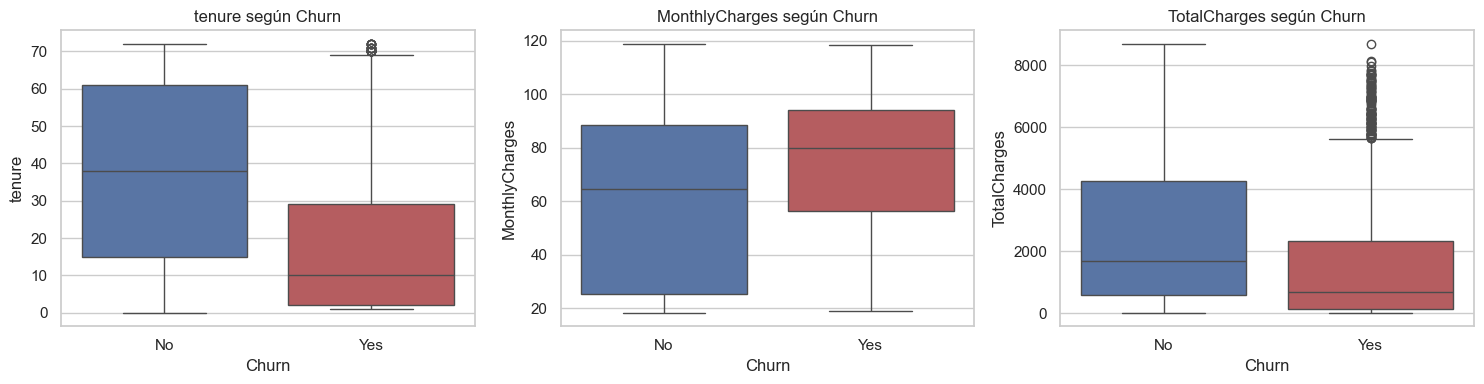

In [7]:
# Se compararán las variables numéricas según el estado de churn (fuga o no fuga).
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['tenure', 'MonthlyCharges', 'TotalCharges']):
    sns.boxplot(x='Churn', y=col, data=df, ax=ax, palette=['#4C72B0', '#C44E52'])
    ax.set_title(f'{col} según Churn')
plt.tight_layout()
plt.show()

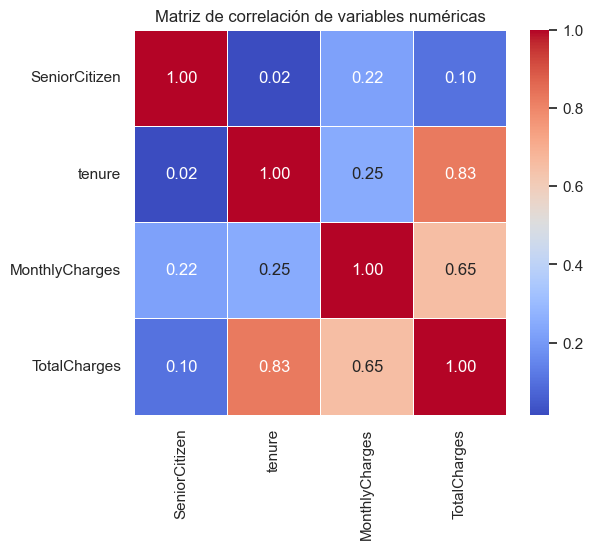

In [8]:
# Se evaluará la correlación entre las variables numéricas mediante una matriz de correlación.
matriz_corr = df[['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de correlación de variables numéricas')
plt.show()

### Conclusiones del análisis exploratorio

- El dataset contiene **7.043 clientes** y **21 columnas**, sin filas duplicadas.
- **`TotalCharges` presenta 11 valores nulos**, todos correspondientes a clientes con `tenure = 0` (clientes nuevos que aún no registran facturación), por lo que podrán imputarse con 0.
- La variable objetivo está **desbalanceada**: un **26,5%** de clientes se fugan frente a un **73,5%** que permanece.
- Los clientes con **contrato mes a mes** presentan la mayor proporción de fuga (~43%), mientras que los contratos de **dos años** apenas superan el 3%.
- Las variables `tenure` y `TotalCharges` están **altamente correlacionadas** (0,83), lo que es esperable ya que el cargo total acumulado depende del tiempo de permanencia.
- Los clientes fugados muestran una **menor antigüedad** (tenure) y, en general, cargos mensuales más altos.

## 2. Preprocesamiento de los datos 

Se limpiarán los datos (imputación de nulos), se transformarán las variables categóricas (codificación) y se normalizarán las variables numéricas, sin modificar el DataFrame original.

In [9]:
# Se creará una función reutilizable que transforma el dataset original en variables listas para modelar.
# La función no modifica el DataFrame de entrada y valida las conversiones críticas.

def preparar_datos(df):
    # Se trabajará sobre una copia para no modificar el DataFrame original.
    datos = df.copy()

    # Se convertirá TotalCharges a numérico de forma segura (validando la conversión).
    datos['TotalCharges'] = pd.to_numeric(datos['TotalCharges'], errors='coerce')

    # Los nulos de TotalCharges corresponden a clientes con tenure = 0 (clientes nuevos),
    # por lo que se imputarán con 0.
    datos['TotalCharges'] = datos['TotalCharges'].fillna(0.0)

    # Los valores "No phone service" y "No internet service" equivalen a "No"
    # y se consolidarán para simplificar la codificación.
    for col in ['MultipleLines']:
        datos[col] = datos[col].replace('No phone service', 'No')
    for col in ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
                'StreamingTV', 'StreamingMovies']:
        datos[col] = datos[col].replace('No internet service', 'No')

    # Se codificará la variable objetivo en formato binario (1 = fuga, 0 = no fuga).
    datos['Churn'] = datos['Churn'].map({'Yes': 1, 'No': 0})

    # Se separarán las variables numéricas y categóricas.
    columnas_numericas = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
    columnas_categoricas = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
                            'InternetService', 'OnlineSecurity', 'OnlineBackup',
                            'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
                            'Contract', 'PaperlessBilling', 'PaymentMethod']

    # Se transformarán las variables categóricas mediante codificación one-hot.
    X = pd.get_dummies(datos[columnas_categoricas], drop_first=True)

    # Se concatenarán las variables numéricas y las variables codificadas.
    X = pd.concat([datos[columnas_numericas].reset_index(drop=True),
                   X.reset_index(drop=True)], axis=1)

    # Variable objetivo.
    y = datos['Churn'].astype(int)

    return X, y

# Se aplicará la función de preparación al dataset original.
X, y = preparar_datos(df)

print('Dimensiones de las características (X):', X.shape)
print('Cantidad de observaciones (y):', y.shape)
print()
print('Sin valores nulos después de la limpieza:', X.isnull().sum().sum() == 0)
print()
X.head()

Dimensiones de las características (X): (7043, 23)
Cantidad de observaciones (y): (7043,)

Sin valores nulos después de la limpieza: True



,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_Yes,InternetService_Fiber optic,...,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,True,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,False,False,...,True,True,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,True,...,False,False,False,False,False,False,True,False,True,False


### Conclusiones del preprocesamiento

- Se imputaron los 11 nulos de `TotalCharges` con 0 (clientes nuevos sin facturación acumulada).
- Se consolidaron los valores "No phone service" / "No internet service" a "No".
- Se aplicó codificación **one-hot** sobre 15 variables categóricas, resultando en un conjunto de características sin valores nulos.
- La **normalización** (escalado) de las variables numéricas se aplicará en la división de los datos, ajustando el escalador únicamente con el conjunto de entrenamiento para evitar fuga de información.

## 3. División en entrenamiento y prueba 

Se dividirá el conjunto de datos en entrenamiento y prueba conservando la proporción de la variable objetivo, y se normalizarán las variables ajustando el escalador solo con datos de entrenamiento.

In [10]:
# Se dividirá el conjunto en entrenamiento (80%) y prueba (20%) de forma estratificada.
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print('Forma de X_train:', X_train.shape)
print('Forma de X_test :', X_test.shape)
print()
print('Distribución de churn en entrenamiento:\n', y_train.value_counts(normalize=True).round(3))
print()
print('Distribución de churn en prueba:\n', y_test.value_counts(normalize=True).round(3))

Forma de X_train: (5634, 23)
Forma de X_test : (1409, 23)

Distribución de churn en entrenamiento:
 Churn
0    0.735
1    0.265
Name: proportion, dtype: float64

Distribución de churn en prueba:
 Churn
0    0.735
1    0.265
Name: proportion, dtype: float64


In [11]:
# Se normalizarán las variables numéricas ajustando el escalador únicamente con el conjunto de entrenamiento,
# para no filtrar información del conjunto de prueba en el entrenamiento.
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

print('Medias (≈0) de las variables normalizadas en entrenamiento:\n', X_train.mean().round(3).head())
print()
print('Desviaciones estándar (≈1) en entrenamiento:\n', X_train.std().round(3).head())
print()
X_train.head()

Medias (≈0) de las variables normalizadas en entrenamiento:
 SeniorCitizen     0.0
tenure           -0.0
MonthlyCharges   -0.0
TotalCharges      0.0
gender_Male       0.0
dtype: float64

Desviaciones estándar (≈1) en entrenamiento:
 SeniorCitizen     1.0
tenure            1.0
MonthlyCharges    1.0
TotalCharges      1.0
gender_Male       1.0
dtype: float64



,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_Yes,InternetService_Fiber optic,...,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,-0.441773,0.102371,-0.521976,-0.262257,0.994336,-0.969234,-0.651557,-3.013090,-0.858338,-0.887696,...,1.375572,-0.643274,1.252163,1.247967,-0.512782,-0.563822,-1.202653,-0.523806,1.406903,-0.543846
1,-0.441773,-0.711743,0.337478,-0.503635,0.994336,1.031742,1.534786,0.331885,-0.858338,1.126512,...,-0.726971,-0.643274,-0.798618,-0.801303,-0.512782,-0.563822,-1.202653,-0.523806,-0.710781,1.838757
2,-0.441773,-0.793155,-0.809013,-0.749883,0.994336,1.031742,1.534786,-3.013090,-0.858338,-0.887696,...,-0.726971,1.554547,-0.798618,-0.801303,-0.512782,1.773611,-1.202653,-0.523806,-0.710781,1.838757
3,-0.441773,-0.263980,0.284384,-0.172722,-1.005696,1.031742,-0.651557,0.331885,-0.858338,-0.887696,...,1.375572,-0.643274,1.252163,1.247967,-0.512782,1.773611,0.831495,1.909105,-0.710781,-0.543846
4,-0.441773,-1.281624,-0.676279,-0.989374,0.994336,1.031742,1.534786,0.331885,-0.858338,-0.887696,...,-0.726971,-0.643274,-0.798618,-0.801303,-0.512782,-0.563822,-1.202653,-0.523806,1.406903,-0.543846


## 4. Entrenamiento de al menos 3 algoritmos y optimización de hiperparámetros 

Se entrenará un **baseline** (clasificador mayoritario) y **cuatro algoritmos** de clasificación: Regresión Logística, Árbol de Decisión, Random Forest y Gradient Boosting. Los hiperparámetros de cada modelo se optimizarán mediante **búsqueda en cuadrícula con validación cruzada** (5 pliegues), optimizando la métrica **F1** por tratarse de un problema desbalanceado.

In [12]:
# Se entrenará un baseline (clasificador mayoritario) como referencia mínima de rendimiento.
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train, y_train)
print('Baseline entrenado. Predicción esperada:', dummy.predict(X_test)[:5])

Baseline entrenado. Predicción esperada: [0 0 0 0 0]


In [13]:
# Se entrenará una Regresión Logística y se optimizarán sus hiperparámetros con validación cruzada.
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

param_grid_log = {'C': [0.01, 0.1, 1, 10]}

grid_log = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=2000),
    param_grid_log, cv=5, scoring='f1', n_jobs=-1)

grid_log.fit(X_train, y_train)
print('Mejores hiperparámetros:', grid_log.best_params_)
print('Mejor F1 (validación cruzada):', round(grid_log.best_score_, 4))

Mejores hiperparámetros: {'C': 10}
Mejor F1 (validación cruzada): 0.5989


In [14]:
# Se entrenará un Árbol de Decisión y se optimizarán sus hiperparámetros con validación cruzada.
from sklearn.tree import DecisionTreeClassifier

param_grid_tree = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 8, None],
    'min_samples_split': [2, 5, 10],
}

grid_tree = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_tree, cv=5, scoring='f1', n_jobs=-1)

grid_tree.fit(X_train, y_train)
print('Mejores hiperparámetros:', grid_tree.best_params_)
print('Mejor F1 (validación cruzada):', round(grid_tree.best_score_, 4))

Mejores hiperparámetros: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_split': 2}
Mejor F1 (validación cruzada): 0.5875


In [15]:
# Se entrenará un Random Forest y se optimizarán sus hiperparámetros con validación cruzada.
from sklearn.ensemble import RandomForestClassifier

param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid_rf, cv=5, scoring='f1', n_jobs=-1)

grid_rf.fit(X_train, y_train)
print('Mejores hiperparámetros:', grid_rf.best_params_)
print('Mejor F1 (validación cruzada):', round(grid_rf.best_score_, 4))

Mejores hiperparámetros: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}
Mejor F1 (validación cruzada): 0.5621


In [16]:
# Se entrenará un Gradient Boosting y se optimizarán sus hiperparámetros con validación cruzada.
from sklearn.ensemble import GradientBoostingClassifier

param_grid_gb = {
    'learning_rate': [0.05, 0.1],
    'n_estimators': [100, 200],
    'max_depth': [3],
}

grid_gb = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid_gb, cv=5, scoring='f1', n_jobs=-1)

grid_gb.fit(X_train, y_train)
print('Mejores hiperparámetros:', grid_gb.best_params_)
print('Mejor F1 (validación cruzada):', round(grid_gb.best_score_, 4))

Mejores hiperparámetros: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}
Mejor F1 (validación cruzada): 0.5792


## 5. Evaluación del rendimiento de los modelos

Se evaluarán los modelos con el conjunto de prueba usando métricas de clasificación pertinentes para problemas desbalanceados: **exactitud (accuracy), precisión, sensibilidad (recall), F1 y área bajo la curva ROC (ROC-AUC)**. La **sensibilidad** es especialmente relevante, ya que interesa detectar la mayor cantidad posible de clientes que realmente se fugan.

In [17]:
# Se evaluarán todos los modelos con el conjunto de prueba.
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report,
                             confusion_matrix, roc_curve)

modelos = {
    'Baseline (mayoritario)': dummy,
    'Regresión Logística': grid_log.best_estimator_,
    'Árbol de Decisión': grid_tree.best_estimator_,
    'Random Forest': grid_rf.best_estimator_,
    'Gradient Boosting': grid_gb.best_estimator_,
}

# Se calcularán las métricas para cada modelo.
resumen = []
for nombre, modelo in modelos.items():
    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:, 1]
    resumen.append({
        'Modelo': nombre,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precisión': precision_score(y_test, y_pred),
        'Sensibilidad (Recall)': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob),
    })

df_resultados = pd.DataFrame(resumen).sort_values('F1', ascending=False)
df_resultados.round(4)

C:\Users\Daniel\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,Modelo,Accuracy,Precisión,Sensibilidad (Recall),F1,ROC-AUC
1,Regresión Logística,0.8048,0.6562,0.5561,0.6020,0.8411
3,Random Forest,0.8020,0.6655,0.5107,0.5779,0.8333
4,Gradient Boosting,0.7999,0.6608,0.5053,0.5727,0.8438
2,Árbol de Decisión,0.7509,0.5273,0.5936,0.5585,0.7871
0,Baseline (mayoritario),0.7346,0.0000,0.0000,0.0000,0.5000


In [18]:
# Se identificará el mejor modelo según el F1 (balance entre precisión y sensibilidad).
mejor_nombre = df_resultados.iloc[0]['Modelo']
mejor_modelo = modelos[mejor_nombre]
print('Mejor modelo:', mejor_nombre)
print()
print('Reporte de clasificación detallado:')
print(classification_report(y_test, mejor_modelo.predict(X_test),
                            target_names=['No fuga', 'Fuga']))

Mejor modelo: Regresión Logística

Reporte de clasificación detallado:
              precision    recall  f1-score   support

     No fuga       0.85      0.89      0.87      1035
        Fuga       0.66      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409



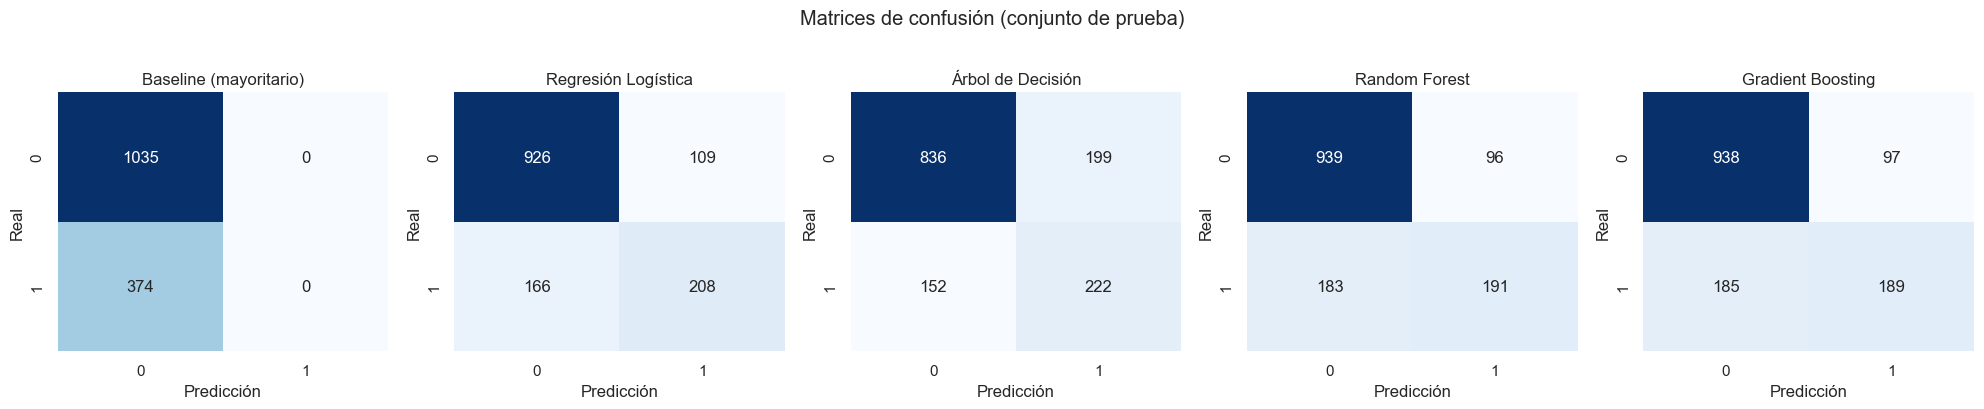

In [19]:
# Se visualizarán las matrices de confusión de todos los modelos.
fig, axes = plt.subplots(1, len(modelos), figsize=(20, 4))
for ax, (nombre, modelo) in zip(axes, modelos.items()):
    cm = confusion_matrix(y_test, modelo.predict(X_test))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
    ax.set_title(nombre)
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Real')
plt.suptitle('Matrices de confusión (conjunto de prueba)', y=1.02)
plt.tight_layout()
plt.show()

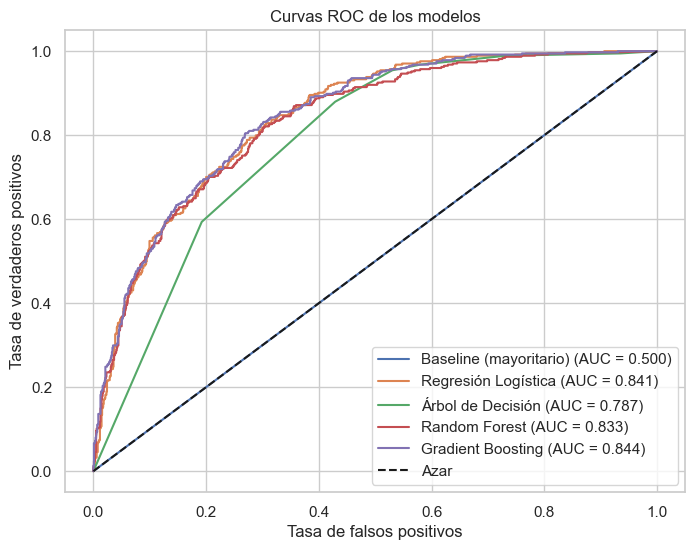

In [20]:
# Se compararán las curvas ROC de los modelos.
plt.figure(figsize=(8, 6))
for nombre, modelo in modelos.items():
    fpr, tpr, _ = roc_curve(y_test, modelo.predict_proba(X_test)[:, 1])
    auc_val = roc_auc_score(y_test, modelo.predict_proba(X_test)[:, 1])
    plt.plot(fpr, tpr, label=f'{nombre} (AUC = {auc_val:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Azar')
plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos')
plt.title('Curvas ROC de los modelos')
plt.legend(loc='lower right')
plt.show()

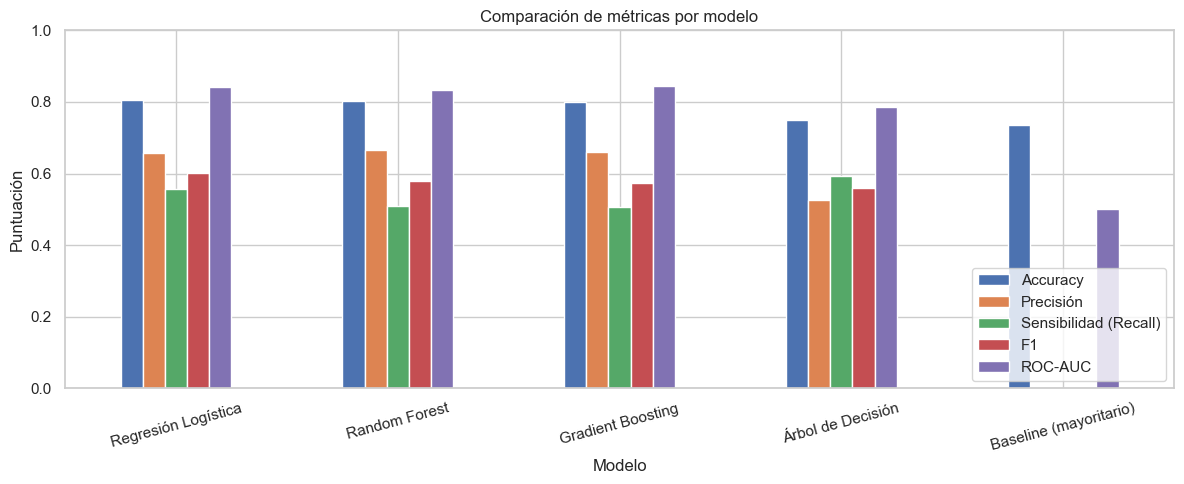

In [21]:
# Se generará un gráfico comparativo de las métricas por modelo.
fig, ax = plt.subplots(figsize=(12, 5))
df_resultados.set_index('Modelo')[['Accuracy', 'Precisión', 'Sensibilidad (Recall)', 'F1', 'ROC-AUC']].plot(
    kind='bar', ax=ax)
ax.set_ylim(0, 1)
ax.set_ylabel('Puntuación')
ax.set_title('Comparación de métricas por modelo')
ax.legend(loc='lower right')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### Conclusiones de la evaluación

- El **baseline mayoritario** (predecir siempre "no fuga") alcanza un 73,46% de exactitud pero **sensibilidad 0**: no detecta ningún cliente fugado, por lo que resulta inútil para el problema de negocio.
- Todos los algoritmos superan ampliamente al baseline. La **Regresión Logística** es el mejor modelo según F1 (**0,6020**) y ROC-AUC (**0,8411**), con un 80,48% de exactitud, 65,62% de precisión y 55,61% de sensibilidad sobre el conjunto de prueba.
- Le siguen de cerca **Random Forest** (F1 = 0,5779, ROC-AUC = 0,8333) y **Gradient Boosting** (F1 = 0,5727, ROC-AUC = 0,8438); el **Árbol de Decisión** presenta el peor desempeño (F1 = 0,5585).
- La sensibilidad más alta corresponde al Árbol de Decisión (59,36%), pero a costa de una precisión notablemente menor (52,73%).
- El modelo ganador (Regresión Logística) detecta correctamente al **56% de los clientes que realmente se fugan** en el conjunto de prueba, lo que permite priorizar acciones de retención; el resto de las métricas queda documentado en la tabla comparativa.
- El modelo ganador se guardó en la carpeta `models/`, junto con el escalador ajustado, para poder reutilizarlo en producción.

In [22]:
# Se guardará el mejor modelo y el escalador en la carpeta models/ para su uso posterior.
import joblib
import os

os.makedirs('models', exist_ok=True)
joblib.dump(mejor_modelo, 'models/mejor_modelo_churn.joblib')
joblib.dump(scaler, 'models/scaler_churn.joblib')

print('Modelo guardado en: models/mejor_modelo_churn.joblib')
print('Escalador guardado en: models/scaler_churn.joblib')

Modelo guardado en: models/mejor_modelo_churn.joblib
Escalador guardado en: models/scaler_churn.joblib
